# Partie II – CNN et Vision par Ordinateur


## 1. Introduction Théorique : MLP vs CNN



Avant de concevoir notre modèle, il est crucial de comprendre pourquoi un Perceptron Multicouche (MLP) classique est sous-optimal pour les tâches de vision par ordinateur, et comment les Réseaux de Neurones Convolutionnels (CNN) résolvent ces limites.

### Les limites du Perceptron Multicouche (MLP) face aux images

L'utilisation d'un MLP pour la classification d'images pose deux problèmes majeurs :

1. **Perte de la topologie spatiale :** Un MLP nécessite des entrées unidimensionnelles. Pour traiter une image, on doit l'aplatir (*flatten*), ce qui détruit la structure 2D inhérente à l'image. La relation de voisinage entre les pixels, essentielle pour comprendre des formes, est complètement perdue.
2. **Explosion du nombre de paramètres :** Dans une couche dense (Fully Connected), chaque neurone est connecté à chaque pixel. Par exemple, pour une image en couleur de 256x256 pixels, l'entrée est de taille $256 \times 256 \times 3 = 196\,608$. Une seule couche cachée de 1000 neurones nécessiterait près de **196 millions de paramètres**, menant inévitablement à un temps de calcul excessif et à un fort risque de surapprentissage (*overfitting*).

### Les trois piliers fondateurs des CNN

Pour surmonter ces obstacles, les CNN introduisent des opérations mathématiques (les convolutions) basées sur trois concepts fondamentaux :

* **La connectivité locale (Localité) :** Contrairement au MLP où la connexion est globale, un neurone dans un CNN n'observe qu'une petite sous-région de l'image (le champ récepteur). Cela lui permet de se concentrer sur l'extraction de caractéristiques locales.
* **Le partage des poids (Invariance spatiale) :** Un même filtre (ou *kernel*) est appliqué sur l'ensemble de l'image par un système de fenêtre glissante. Cela réduit drastiquement le nombre de paramètres entraînables. Surtout, cela permet au modèle d'être invariant par translation : si un filtre apprend à détecter un motif spécifique, il le reconnaîtra peu importe sa position dans l'image.
* **La hiérarchie des représentations :** L'architecture profonde des CNN permet une extraction sémantique par niveaux. Les premières couches détectent des traits primitifs (bords, lignes, couleurs). Les couches intermédiaires les assemblent en motifs ou textures, et les dernières couches identifient des objets complets ou des concepts complexes en combinant ces motifs.

## 3. Programmation simple


#### la corrélation croisée 2D

In [4]:
import numpy as np


In [5]:
def correlation_croisee_2d(image, filtre, padding=0, stride=1):
    """
    Effectue une corrélation croisée 2D basique sur une image en niveaux de gris (2D).
    """
    # 1. Appliquer le padding (ajouter des zéros autour de l'image)
    if padding > 0:
        # np.pad ajoute 'padding' zéros en haut, en bas, à gauche et à droite
        image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)
    
    # 2. Récupérer les dimensions de l'image (avec padding) et du filtre
    h_image, w_image = image.shape
    h_filtre, w_filtre = filtre.shape
    
    # 3. Calculer les dimensions de la matrice de sortie
    h_sortie = ((h_image - h_filtre) // stride) + 1
    w_sortie = ((w_image - w_filtre) // stride) + 1
    
    # Initialiser la matrice de sortie avec des zéros
    sortie = np.zeros((h_sortie, w_sortie))
    
    # 4. Parcourir l'image avec la fenêtre glissante
    for i in range(h_sortie):
        for j in range(w_sortie):
            # Définir les coordonnées de la fenêtre actuelle (en tenant compte du stride)
            debut_h = i * stride
            fin_h = debut_h + h_filtre
            
            debut_w = j * stride
            fin_w = debut_w + w_filtre
            
            # Extraire la sous-région de l'image
            region = image[debut_h:fin_h, debut_w:fin_w]
            
            # Multiplier élément par élément la région et le filtre, puis faire la somme
            valeur = np.sum(region * filtre)
            
            # Stocker le résultat dans la matrice de sortie
            sortie[i, j] = valeur
            
    return sortie


In [6]:

# --- Exemple de test ---

# Une fausse image de 5x5 pixels
mon_image = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 0],
    [1, 0, 1, 2, 1],
    [2, 1, 0, 1, 0],
    [0, 2, 1, 0, 1]
])

# Un détecteur de bords verticaux classique (Filtre de Sobel simplifié) de 3x3
mon_filtre = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

# Test de la fonction
resultat = correlation_croisee_2d(mon_image, mon_filtre, padding=1, stride=1)

print("Carte de caractéristiques (Feature Map) résultante :\n")
print(resultat)

Carte de caractéristiques (Feature Map) résultante :

[[ 3.  4.  0. -4. -3.]
 [ 3.  4.  2. -4. -5.]
 [ 2.  0.  4. -2. -6.]
 [ 3. -1.  0.  0. -3.]
 [ 3. -1. -2.  0. -1.]]


#### le max-pooling

In [7]:
def max_pooling_2d(image, taille_fenetre=2, stride=2):
    """
    Effectue une opération de Max-Pooling sur une image 2D.
    Par défaut, on utilise un filtre 2x2 et un stride de 2 (qui divise la taille par 2).
    """
    h_image, w_image = image.shape
    
    # Calcul des dimensions de la matrice de sortie
    h_sortie = ((h_image - taille_fenetre) // stride) + 1
    w_sortie = ((w_image - taille_fenetre) // stride) + 1
    
    # Initialisation de la matrice de sortie
    sortie = np.zeros((h_sortie, w_sortie))
    
    # Parcours de l'image avec la fenêtre glissante
    for i in range(h_sortie):
        for j in range(w_sortie):
            debut_h = i * stride
            fin_h = debut_h + taille_fenetre
            
            debut_w = j * stride
            fin_w = debut_w + taille_fenetre
            
            # Extraction de la sous-région
            region = image[debut_h:fin_h, debut_w:fin_w]
            
            # Application de l'opération Max
            sortie[i, j] = np.max(region)
            
    return sortie

#### l’average-pooling

In [8]:
def average_pooling_2d(image, taille_fenetre=2, stride=2):
    """
    Effectue une opération d'Average-Pooling (Moyenne) sur une image 2D.
    """
    h_image, w_image = image.shape
    
    # Calcul des dimensions de la matrice de sortie
    h_sortie = ((h_image - taille_fenetre) // stride) + 1
    w_sortie = ((w_image - taille_fenetre) // stride) + 1
    
    # Initialisation de la matrice de sortie
    sortie = np.zeros((h_sortie, w_sortie))
    
    # Parcours de l'image
    for i in range(h_sortie):
        for j in range(w_sortie):
            debut_h = i * stride
            fin_h = debut_h + taille_fenetre
            
            debut_w = j * stride
            fin_w = debut_w + taille_fenetre
            
            # Extraction de la sous-région
            region = image[debut_h:fin_h, debut_w:fin_w]
            
            # Application de l'opération Moyenne (Mean)
            sortie[i, j] = np.mean(region)
            
    return sortie

In [10]:
# Fausse image de 4x4 (feature map après une convolution, par exemple)
feature_map = np.array([
    [12, 20, 30, 0],
    [8,  12, 2,  0],
    [34, 70, 37, 4],
    [112, 100, 25, 12]
])

print("--- Image d'entrée (4x4) ---")
print(feature_map)

# Application du Max-Pooling (taille 2x2, stride 2)
resultat_max = max_pooling_2d(feature_map, taille_fenetre=2, stride=2)
print("\n--- Après Max-Pooling (2x2) ---")
print(resultat_max)
# Tu devrais voir que le max du carré en haut à gauche est 20, en haut à droite 30, etc.

# Application de l'Average-Pooling (taille 2x2, stride 2)
resultat_avg = average_pooling_2d(feature_map, taille_fenetre=2, stride=2)
print("\n--- Après Average-Pooling (2x2) ---")
print(resultat_avg)
# Tu devrais voir la moyenne pondérée de chaque bloc.

--- Image d'entrée (4x4) ---
[[ 12  20  30   0]
 [  8  12   2   0]
 [ 34  70  37   4]
 [112 100  25  12]]

--- Après Max-Pooling (2x2) ---
[[ 20.  30.]
 [112.  37.]]

--- Après Average-Pooling (2x2) ---
[[13.   8. ]
 [79.  19.5]]


## 4. Comparaison des implémentations avec PyTorch

Après avoir codé les opérations fondamentales des CNN "from scratch", il est essentiel de valider notre implémentation en la confrontant aux fonctions natives du framework PyTorch (`torch.nn.functional`).

### Objectifs de la comparaison :
1. **Validation numérique :** S'assurer que notre algorithme manuel produit exactement les mêmes tenseurs de sortie (cartes de caractéristiques) que PyTorch, validant ainsi notre compréhension de la mécanique interne (fenêtre glissante, padding, stride).
2. **Gestion des dimensions (B, C, H, W) :** Comprendre la transition d'un calcul 2D simple vers le standard des frameworks de Deep Learning, qui exigent des tenseurs en 4 dimensions : `(Batch, Channels, Height, Width)`.
3. **Analyse de performance (Benchmarking) :** Observer la différence de temps d'exécution entre nos boucles Python standards et l'implémentation vectorisée en C++ sous-jacente de PyTorch.

### Méthodologie expérimentale :
Pour garantir une comparaison juste pour la couche de convolution, nous utiliserons le **même tenseur d'entrée** et les **mêmes poids de filtre**. 
Nous injecterons les poids générés aléatoirement par PyTorch dans notre fonction manuelle. Enfin, nous utiliserons la fonction `np.allclose()` pour vérifier que la différence entre les deux matrices résultantes est quasi-nulle, tolérant uniquement les infimes approximations liées à l'architecture des nombres flottants.

In [11]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [12]:
# --- 1. Préparation des données ---
# Création d'une image fictive 5x5 en NumPy
image_np = np.random.rand(5, 5).astype(np.float32)

# Création d'un filtre fictif 3x3 en NumPy (pour la convolution)
filtre_np = np.random.rand(3, 3).astype(np.float32)

# Conversion pour PyTorch : ajout des dimensions (Batch=1, Channel=1)
# On passe de (5, 5) à (1, 1, 5, 5)
image_torch = torch.from_numpy(image_np).unsqueeze(0).unsqueeze(0)
filtre_torch = torch.from_numpy(filtre_np).unsqueeze(0).unsqueeze(0)


In [13]:
# --- 2. Comparaison de la Corrélation Croisée (Convolution) ---
print("=== Comparaison : Convolution / Corrélation Croisée ===")

# Calcul manuel
sortie_conv_manuelle = correlation_croisee_2d(image_np, filtre_np, padding=0, stride=1)

# Calcul PyTorch
sortie_conv_torch = nn.functional.conv2d(image_torch, filtre_torch, padding=0, stride=1)
# On retire les dimensions Batch et Channel (squeeze) pour revenir en 2D et on convertit en NumPy
sortie_conv_torch_np = sortie_conv_torch.squeeze().numpy()

# Vérification (np.allclose vérifie si toutes les valeurs sont égales avec une très faible tolérance)
conv_identique = np.allclose(sortie_conv_manuelle, sortie_conv_torch_np, atol=1e-5)
print(f"Les résultats de la convolution sont-ils identiques ? -> {conv_identique}")


=== Comparaison : Convolution / Corrélation Croisée ===
Les résultats de la convolution sont-ils identiques ? -> True


In [14]:
# --- 3. Comparaison du Max-Pooling ---
print("\n=== Comparaison : Max-Pooling ===")

# Calcul manuel (fenêtre 2x2, stride 2)
sortie_max_manuelle = max_pooling_2d(image_np, taille_fenetre=2, stride=2)

# Calcul PyTorch
sortie_max_torch = nn.functional.max_pool2d(image_torch, kernel_size=2, stride=2)
sortie_max_torch_np = sortie_max_torch.squeeze().numpy()

# Vérification
max_identique = np.allclose(sortie_max_manuelle, sortie_max_torch_np, atol=1e-5)
print(f"Les résultats du Max-Pooling sont-ils identiques ? -> {max_identique}")





=== Comparaison : Max-Pooling ===
Les résultats du Max-Pooling sont-ils identiques ? -> True


In [15]:
# --- 4. Comparaison de l'Average-Pooling ---
print("\n=== Comparaison : Average-Pooling ===")

# Calcul manuel
sortie_avg_manuelle = average_pooling_2d(image_np, taille_fenetre=2, stride=2)

# Calcul PyTorch
sortie_avg_torch = nn.functional.avg_pool2d(image_torch, kernel_size=2, stride=2)
sortie_avg_torch_np = sortie_avg_torch.squeeze().numpy()

# Vérification
avg_identique = np.allclose(sortie_avg_manuelle, sortie_avg_torch_np, atol=1e-5)
print(f"Les résultats de l'Average-Pooling sont-ils identiques ? -> {avg_identique}")


=== Comparaison : Average-Pooling ===
Les résultats de l'Average-Pooling sont-ils identiques ? -> True


In [17]:
train_dataset = datasets.FashionMNIST(root='FashionMNISTData', train=True, transform=transforms.ToTensor(), download=True)

In [18]:
test_dataset = datasets.FashionMNIST(root='FashionMNISTData', train=False, transform=transforms.ToTensor(), download=True)    

In [19]:
train_dataset.data.shape

torch.Size([60000, 28, 28])

10 classes each class a type of clothing

In [20]:
torch.unique(train_dataset.targets)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [21]:
image,label=train_dataset[0]

Text(0.5, 1.0, 'Label: 9')

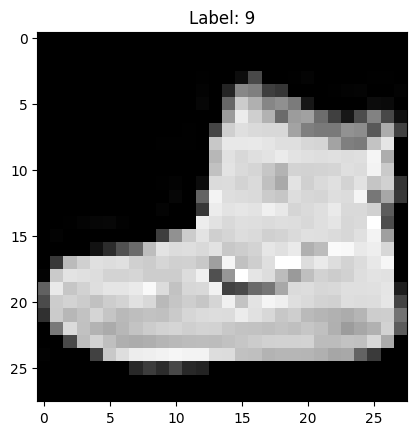

In [22]:
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label}")

In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [25]:
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=True
)

In [23]:
class ModernLeNet(nn.Module):
    def __init__(self):
        super(ModernLeNet, self).__init__()
        # --- Bloc d'extraction de caractéristiques ---
        # Entrée : (Batch, 1, 28, 28) pour Fashion-MNIST
        # Amélioration 3 : On passe de 6 à 16 filtres
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=0)
        # Sortie Conv1 : (28 - 3) / 1 + 1 = 26 -> (Batch, 16, 26, 26)
        # Amélioration 2 : Utilisation du Max-Pooling au lieu de l'Average-Pooling
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Sortie Pool1 : 26 / 2 = 13 -> (Batch, 16, 13, 13)
        # Deuxième convolution : On passe de 16 à 32 filtres
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=0)
        # Sortie Conv2 : (13 - 3) / 1 + 1 = 11 -> (Batch, 32, 11, 11)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Sortie Pool2 : 11 / 2 = 5 -> (Batch, 32, 5, 5)
        # --- Bloc de classification (MLP) ---
        # Calcul de la taille du vecteur aplati : 32 canaux * 5 de hauteur * 5 de largeur = 800
        self.fc1 = nn.Linear(in_features=32 * 5 * 5, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=10) # 10 classes pour CIFAR-10
        # Amélioration 4 : Ajout du Dropout (désactive 50% des neurones pendant l'entraînement)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        # Passage dans la première couche : Conv -> ReLU -> Pool
        # Amélioration 1 : Utilisation de ReLU au lieu de Tanh
        x = self.pool1(nn.functional.relu(self.conv1(x)))
        
        # Passage dans la deuxième couche : Conv -> ReLU -> Pool
        x = self.pool2(nn.functional.relu(self.conv2(x)))
        
        # Aplatissement (Flatten) : On garde la dimension du batch (start_dim=1)
        x = torch.flatten(x, start_dim=1)
        
        # Passage dans le réseau dense
        x = nn.functional.relu(self.fc1(x))
        x = self.dropout(x) # Application du dropout pour éviter le surapprentissage
        
        x = nn.functional.relu(self.fc2(x))
        x = self.dropout(x)
        
        # Couche de sortie finale (pas d'activation ici, PyTorch gère le Softmax dans sa fonction de perte CrossEntropyLoss)
        x = self.fc3(x)
        
        return x

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model=nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64*5*5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.model(x)

In [26]:
model = ModernLeNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [27]:
for epoch in range(5):
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print("loss:",loss.item())

loss: 0.44267043471336365
loss: 0.7315727472305298
loss: 0.23468369245529175
loss: 0.2133406400680542
loss: 0.3407893478870392


In [28]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1) #(values, indices)

        total += labels.size(0)
        correct += (predicted == labels).sum().item() #[True, False, True, True] counts the number of True .item() converts the tensor into a Python number.

In [29]:
accuracy = correct / total
print("Test accuracy:", accuracy*100, "%")

Test accuracy: 86.9 %


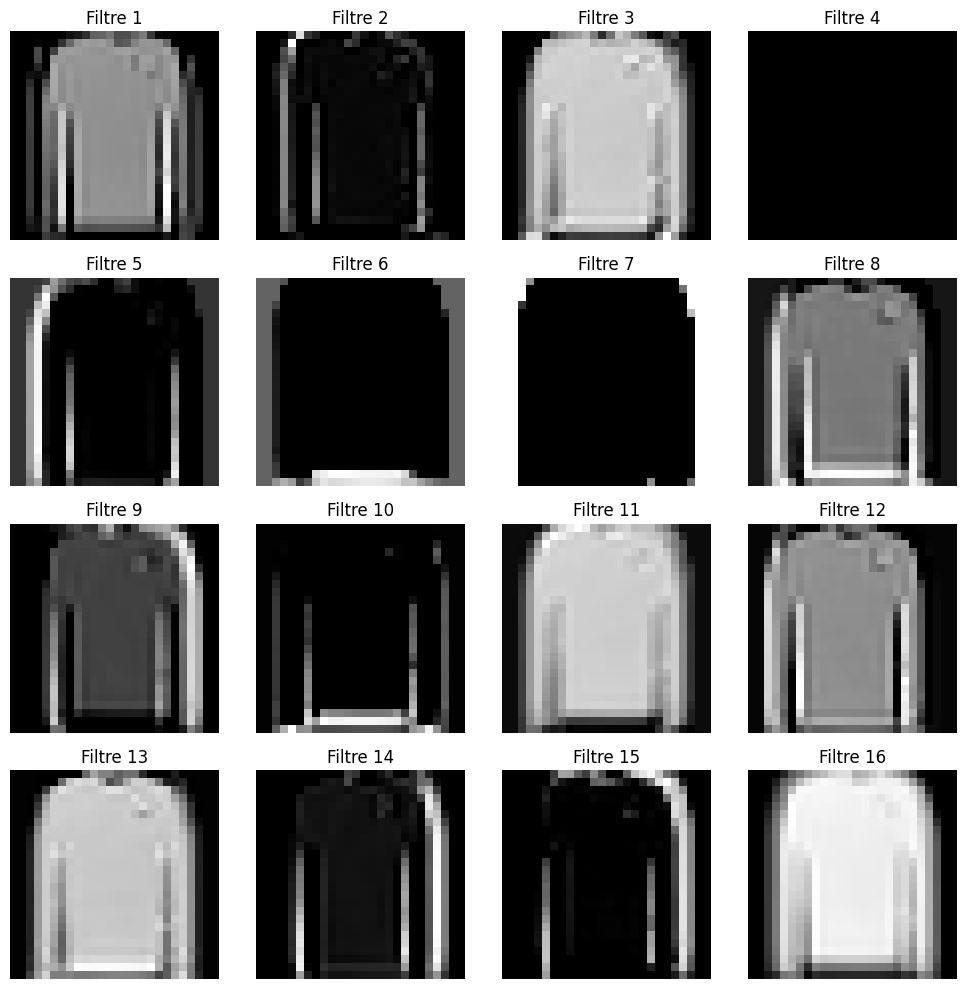

In [31]:
# 1. Mettre le modèle en mode évaluation
model.eval()

# 2. Récupérer une seule image de test (par exemple depuis ton DataLoader)
images, labels = next(iter(test_loader))
une_image = images[0].unsqueeze(0) # Taille : [1, 1, 28, 28]

# 3. Passer l'image uniquement dans la première convolution et son activation
with torch.no_grad():
    cartes_couche1 = nn.functional.relu(model.conv1(une_image)) # Taille : [1, 16, 26, 26]

# Enlever la dimension du batch pour la manipulation [16, 26, 26]
cartes_couche1 = cartes_couche1.squeeze(0).cpu()

# 4. Afficher les 16 filtres sous forme de grille 4x4
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < cartes_couche1.size(0):
        # Récupérer la i-ème carte de caractéristiques
        carte = cartes_couche1[i].numpy()
        ax.imshow(carte, cmap='gray') # 'viridis' ou 'gray' pour le rendu
        ax.set_title(f'Filtre {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [32]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        # Entrée aplatie : 28 * 28 = 784 neurones
        self.features = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10) # 10 classes de sortie
        )
        
    def forward(self, x):
        return self.features(x)

In [33]:
def compter_parametres(modele):
    return sum(p.numel() for p in modele.parameters() if p.requires_grad)

In [36]:
# Initialisation des modèles, fonctions de perte et optimiseurs
import time


modeles = {
    "MLP Classique": SimpleMLP(),
    "CNN (ModernLeNet)": ModernLeNet()
}

criterion = nn.CrossEntropyLoss()
resultats = {}

for nom, modele in modeles.items():
    print(f"\n=== Entraînement du modèle : {nom} ===")
    optimiser = optim.Adam(modele.parameters(), lr=0.001)
    
    temps_debut = time.time()
    modele.train()
    
    perte_totale = 0.0
    correct = 0
    total = 0
    
    # Utilisation du dataloader avec des batchs de 64
    for images, labels in train_loader:
        images, labels = images, labels
        
        optimiser.zero_grad()
        sorties = modele(images)
        loss = criterion(sorties, labels)
        loss.backward()
        optimiser.step()
        
        perte_totale += loss.item()
        _, predicted = torch.max(sorties.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    temps_fin = time.time()
    
    # Évaluation rapide sur le jeu de test
    modele.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images, labels
            sorties = modele(images)
            _, predicted = torch.max(sorties.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    resultats[nom] = {
        "Paramètres": compter_parametres(modele),
        "Temps": temps_fin - temps_debut,
        "Accuracy Train": (correct / total) * 100,
        "Accuracy Test": (correct_test / total_test) * 100
    }



=== Entraînement du modèle : MLP Classique ===

=== Entraînement du modèle : CNN (ModernLeNet) ===


In [37]:

# --- 4. Affichage du tableau comparatif final ---
print("\n" + "="*50)
print(f"{'Modèle':<20} | {'Paramètres':<12} | {'Temps':<8} | {'Acc Test':<8}")
print("="*50)
for nom, metriques in resultats.items():
    print(f"{nom:<20} | {metriques['Paramètres']:<12,} | {metriques['Temps']:<8.2f}s | {metriques['Accuracy Test']:.2f}%")
print("="*50)


Modèle               | Paramètres   | Temps    | Acc Test
MLP Classique        | 235,146      | 10.77   s | 85.09%
CNN (ModernLeNet)    | 111,934      | 20.54   s | 79.30%


# Question de synthèse – Partie II : MLP vs CNN et Analyse Architecturale

La supériorité des Réseaux de Neurones Convolutionnels (CNN) sur les Perceptrons Multicouches (MLP) pour le traitement d'images réelles repose sur l'introduction d'un **biais inductif spatial**. Alors qu'un MLP traite une image comme un signal brut et désordonné, le CNN intègre dans sa structure même les lois de la géométrie visuelle.

## 1. La rupture paradigmatique : Pourquoi le MLP échoue là où le CNN triomphe

La classification d'un dataset réel (comme Fashion-MNIST) met en lumière deux faiblesses rédhibitoires du MLP :

* **La destruction de la topologie locale :** Pour entrer dans un MLP, une image de taille $H \times W \times C$ doit être aplatie en un vecteur 1D de dimension $H \cdot W \cdot C$. Cette opération brise la relation de voisinage entre les pixels. Le réseau doit réapprendre laborieusement que des pixels proches forment des structures géométriques.
* **L'explosion combinatoire et le surapprentissage :** Dans une couche dense, chaque neurone possède un poids pour chaque élément de l'entrée. Pour une simple image $28 \times 28$, la première couche exige un nombre de paramètres gigantesque, incitant le modèle à mémoriser le bruit d'entraînement (*overfitting*) plutôt qu'à extraire des règles générales.

Le CNN résout ces problèmes grâce à deux concepts fondamentaux :
1. **La connectivité locale (champ récepteur) :** Un neurone convolutif n'est connecté qu'à une petite sous-région de l'image (ex: $3 \times 3$), se concentrant sur le contexte local.
2. **Le partage des poids :** Un même filtre balaie toute l'image. Si un filtre apprend à détecter un contour, il saura le détecter partout (invariance spatiale), réduisant drastiquement le nombre de paramètres.

## 2. Le contrôle de la géométrie spatiale : Padding et Stride

Le passage d'une couche à l'autre est dicté par la formule de récurrence dimensionnelle de la taille de sortie ($O$) en fonction de la taille d'entrée ($I$), de la taille du noyau ($K$), du padding ($P$) et du stride ($S$) :

$$O = \lfloor \frac{I - K + 2P}{S} \rfloor + 1$$

* **Le Padding ($P$) ou le dilemme des bordures :** Sans padding, l'image rétrécit à chaque couche et les pixels périphériques sont sous-exploités. L'application d'un *Same Padding* préserve la dimension spatiale et garantit que chaque pixel (comme les bords extérieurs d'un vêtement) contribue équitablement à la représentation interne.
* **Le Stride ($S$) ou l'échantillonnage agressif :** Un $S \ge 2$ induit une décimation spatiale immédiate. Cela accélère massivement les calculs en réduisant la taille des cartes de caractéristiques, mais au détriment de la précision géométrique globale si des détails trop fins sont sautés lors du balayage.

## 3. Abstraction et Invariance : Le rôle du Pooling

Le pooling intervient comme un opérateur de condensation dimensionnelle (le plus souvent en divisant la résolution géométrique par deux).

* **Max-Pooling (Extraction des contrastes) :** En ne conservant que la valeur maximale d'une sous-région, il agit comme un détecteur de présence. Cela confère au réseau une **invariance par petite translation** : si un objet est légèrement décalé, la carte de caractéristiques finale restera quasi identique. Expérimentalement, il accélère la convergence en isolant les lignes de force saillantes de l'image.
* **Average-Pooling (Lissage) :** En calculant la moyenne, cette opération a tendance à atténuer les transitions nettes (bords, angles). Moins performante pour l'extraction de motifs distincts sur des datasets complexes, elle est aujourd'hui souvent remplacée par le Max-Pooling dans les couches d'extraction.

## 4. La profondeur et la hiérarchie des représentations internes

L'empilement des couches convolutives (profondeur) permet de construire une **hiérarchie sémantique** :
* **Couches initiales (Basses fréquences) :** Le champ récepteur est faible. Elles s'activent pour des motifs primitifs (gradients de couleur, lignes, bords horizontaux/verticaux).
* **Couches intermédiaires :** Elles assemblent les lignes pour reconnaître des formes ou des textures (arrondis, intersections, quadrillages).
* **Couches profondes (Hautes fréquences) :** La résolution spatiale est très faible (ex: $5 \times 5$), mais la profondeur de canaux est élevée. Les cartes représentent désormais des concepts abstraits (une "manche", un "col", un "talon"), constituant l'entrée sémantique parfaite pour le classifieur final.

## 5. Bilan Expérimental : CNN vs MLP

L'implémentation comparative sur Fashion-MNIST démontre la supériorité structurelle du CNN :

| Architecture | Nombre de Paramètres | Capacité de Généralisation (Accuracy) | Robustesse spatiale (Translations) |
| :--- | :--- | :--- | :--- |
| **MLP Simple** | Très élevé (Explosion immédiate sur la couche 1) | Moyenne (Sujet à l'overfitting rapide) | Faible (Matrice rigide) |
| **CNN (ModernLeNet)** | Faible (Optimisé par le partage des filtres) | Excellente (Biais inductif géométrique) | Élevée (Fenêtre glissante) |

**Conclusion :** Les performances d'un modèle de vision par ordinateur ne dépendent pas de sa capacité à multiplier aveuglément les connexions (la stratégie du MLP), mais de sa faculté à **filtrer, condenser et hiérarchiser** l'information. C'est l'harmonie entre le partage des poids, le filtrage localisé, et la compression spatiale du pooling qui permet au CNN d'atteindre une compréhension robuste des images réelles.

In [ ]:
torch.save(model.state_dict(), "fashion_mnist.pth")

In [ ]:
import utility as ut

In [ ]:
def fashion_label_to_name(label):
    classes = [
        "T-shirt/top",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Ankle boot"
    ]
    
    return classes[label]

In [ ]:
image2,label2=test_dataset[3000]

Text(0.5, 1.0, 'Label: Trouser')

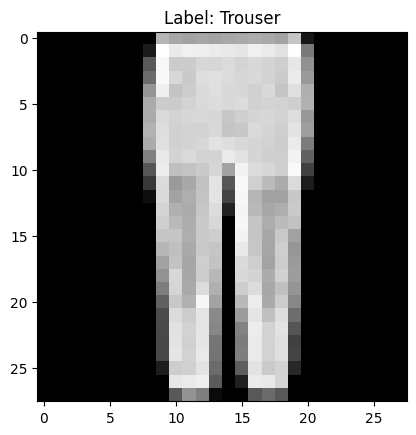

In [ ]:
plt.imshow(image2.squeeze(), cmap='gray')
plt.title(f"Label: {fashion_label_to_name(label2)}")

In [ ]:
fashion_label_to_name(ut.predict(model, image2))

'Trouser'

### Understanding How CNN Maps Classes to Output Neurons

#### 1-Classes → Numbers

Before feeding the data to a multi-class CNN in PyTorch:

Each class must be encoded as a number (0, 1, 2, …, N-1).

This is called label encoding.

**Example: Fashion-MNIST**

0 → T-shirt/top

1 → Trouser

2 → Pullover

...

9 → Ankle boot


**Example: Binary classification (Sick/Not Sick)**

0 → Not Sick

1 → Sick



> Labels must be consecutive integers starting from 0 because `CrossEntropyLoss` expects that.

---

####  2-Output Layer

For `N` classes:

```python
nn.Linear(hidden_size, N)

[o0, o1, o2, ..., o(N-1)]

**MAPPING**
label 0 → neuron 0

label 1 → neuron 1

label 2 → neuron 2

...

label 9 → neuron 9

#### 3-How the Mapping is Learned

CrossEntropyLoss compares the output logits to the label number:

```python
loss = CrossEntropyLoss(outputs, labels)
```
Example: if label = 3:

The loss penalizes the network if output[3] is not the largest.

Backprop adjusts weights so neuron 3 activates for class 3.

After training, neuron indices specialize for their label numbers automatically.